In [1]:
from google.colab import files
print("upload kaggle.json")
uploaded = files.upload()

upload kaggle.json


Saving kaggle (1).json to kaggle (1).json


In [2]:
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/data/ --unzip

print("dataset downloaded")

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 182MB/s]

dataset downloaded


In [3]:
import os
import glob
import random

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.utils import to_categorical

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
DATASET_PATH = "/content/data/Training"

IMG_SIZE = 128

CLASSES = [
    "notumor",
    "glioma",
    "meningioma",
    "pituitary"
]

In [6]:
def load_images(class_name, label):

    folder = os.path.join(DATASET_PATH, class_name)

    image_paths = sorted(
        glob.glob(os.path.join(folder, "*.jpg")) +
        glob.glob(os.path.join(folder, "*.png")) +
        glob.glob(os.path.join(folder, "*.jpeg"))
    )

    images = []
    labels = []

    for path in image_paths:

        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img.astype(np.float32) / 255.0

        images.append(img)
        labels.append(label)

    return np.array(images), np.array(labels)

In [7]:
X = []
y = []

for label, class_name in enumerate(CLASSES):

    print(f"Loading {class_name} ...")

    images, labels = load_images(class_name, label)

    X.extend(images)
    y.extend(labels)

    print(f"Loaded {len(images)} images")

X = np.array(X)
y = np.array(y)

# Add channel dimension
X = X[..., np.newaxis]

print("\nDataset Loaded Successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Loading notumor ...
Loaded 1400 images
Loading glioma ...
Loaded 1400 images
Loading meningioma ...
Loaded 1400 images
Loading pituitary ...
Loaded 1400 images

Dataset Loaded Successfully!
X shape: (5600, 128, 128, 1)
y shape: (5600,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("Training images :", X_train.shape)
print("Testing images  :", X_test.shape)

Training images : (4480, 128, 128, 1)
Testing images  : (1120, 128, 128, 1)


In [9]:
print("Training Set")

for i, name in enumerate(CLASSES):
    print(f"{name:12s}: {(y_train==i).sum()}")

print("\nTesting Set")

for i, name in enumerate(CLASSES):
    print(f"{name:12s}: {(y_test==i).sum()}")

Training Set
notumor     : 1120
glioma      : 1120
meningioma  : 1120
pituitary   : 1120

Testing Set
notumor     : 280
glioma      : 280
meningioma  : 280
pituitary   : 280


In [10]:
y_train_cat = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes=4)

print(y_train_cat.shape)
print(y_test_cat.shape)

(4480, 4)
(1120, 4)


In [11]:
print("="*50)
print("Dataset Summary")
print("="*50)

print(f"Total Images : {len(X)}")
print(f"Image Shape  : {X.shape[1:]}")
print(f"Number of Classes : {len(CLASSES)}")

for i, cls in enumerate(CLASSES):
    print(f"{cls:12s}: {(y==i).sum()}")

Dataset Summary
Total Images : 5600
Image Shape  : (128, 128, 1)
Number of Classes : 4
notumor     : 1400
glioma      : 1400
meningioma  : 1400
pituitary   : 1400


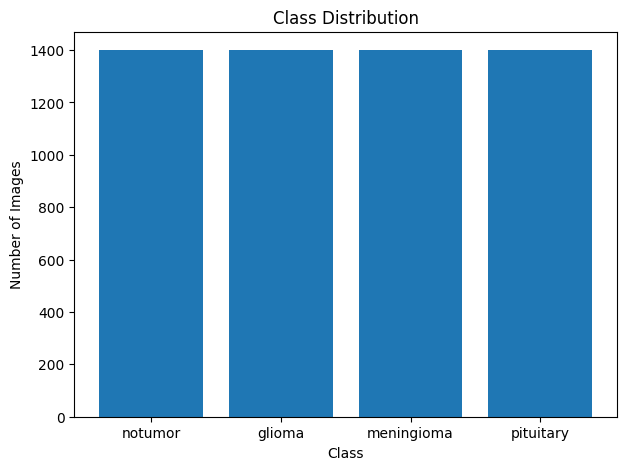

In [12]:
counts = [np.sum(y == i) for i in range(len(CLASSES))]

plt.figure(figsize=(7,5))
plt.bar(CLASSES, counts)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

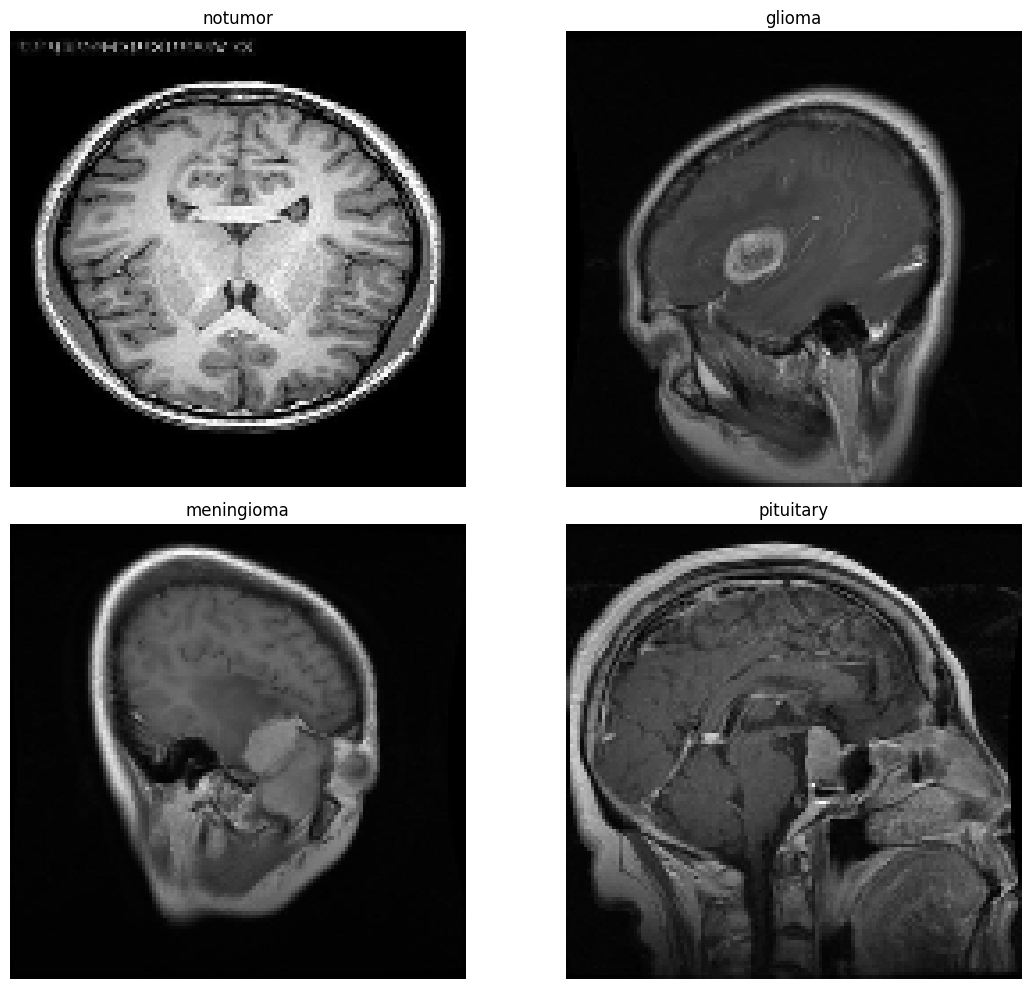

In [13]:
plt.figure(figsize=(12,10))

for i, cls in enumerate(CLASSES):

    idx = np.random.choice(np.where(y == i)[0])

    plt.subplot(2,2,i+1)
    plt.imshow(X[idx].squeeze(), cmap="gray")
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

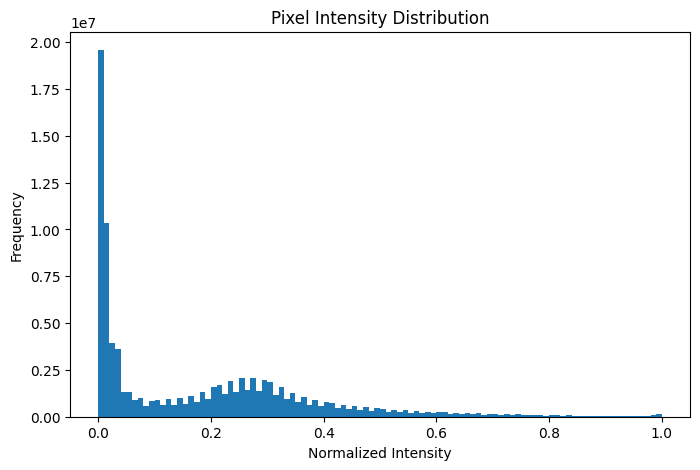

In [14]:
plt.figure(figsize=(8,5))

plt.hist(
    X.flatten(),
    bins=100
)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Normalized Intensity")
plt.ylabel("Frequency")

plt.show()

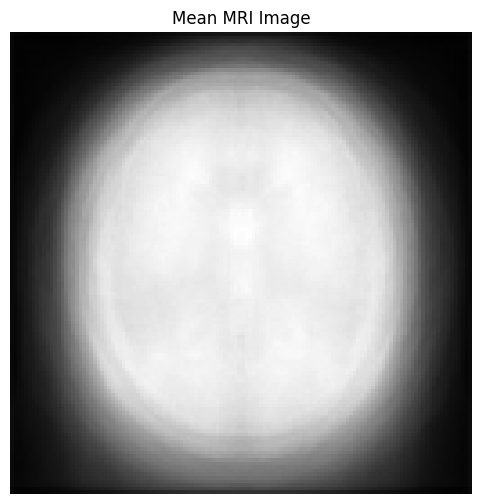

In [15]:
mean_image = np.mean(X, axis=0)

plt.figure(figsize=(6,6))
plt.imshow(mean_image.squeeze(), cmap="gray")
plt.title("Mean MRI Image")
plt.axis("off")

plt.show()

In [16]:
print("Minimum pixel :", np.min(X))
print("Maximum pixel :", np.max(X))
print("Mean pixel    :", np.mean(X))
print("Std pixel     :", np.std(X))

Minimum pixel : 0.0
Maximum pixel : 1.0
Mean pixel    : 0.18410166
Std pixel     : 0.19923088


In [17]:
unique_shapes = set(img.shape for img in X)

print(unique_shapes)

{(128, 128, 1)}


In [18]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.08),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

], name="data_augmentation")

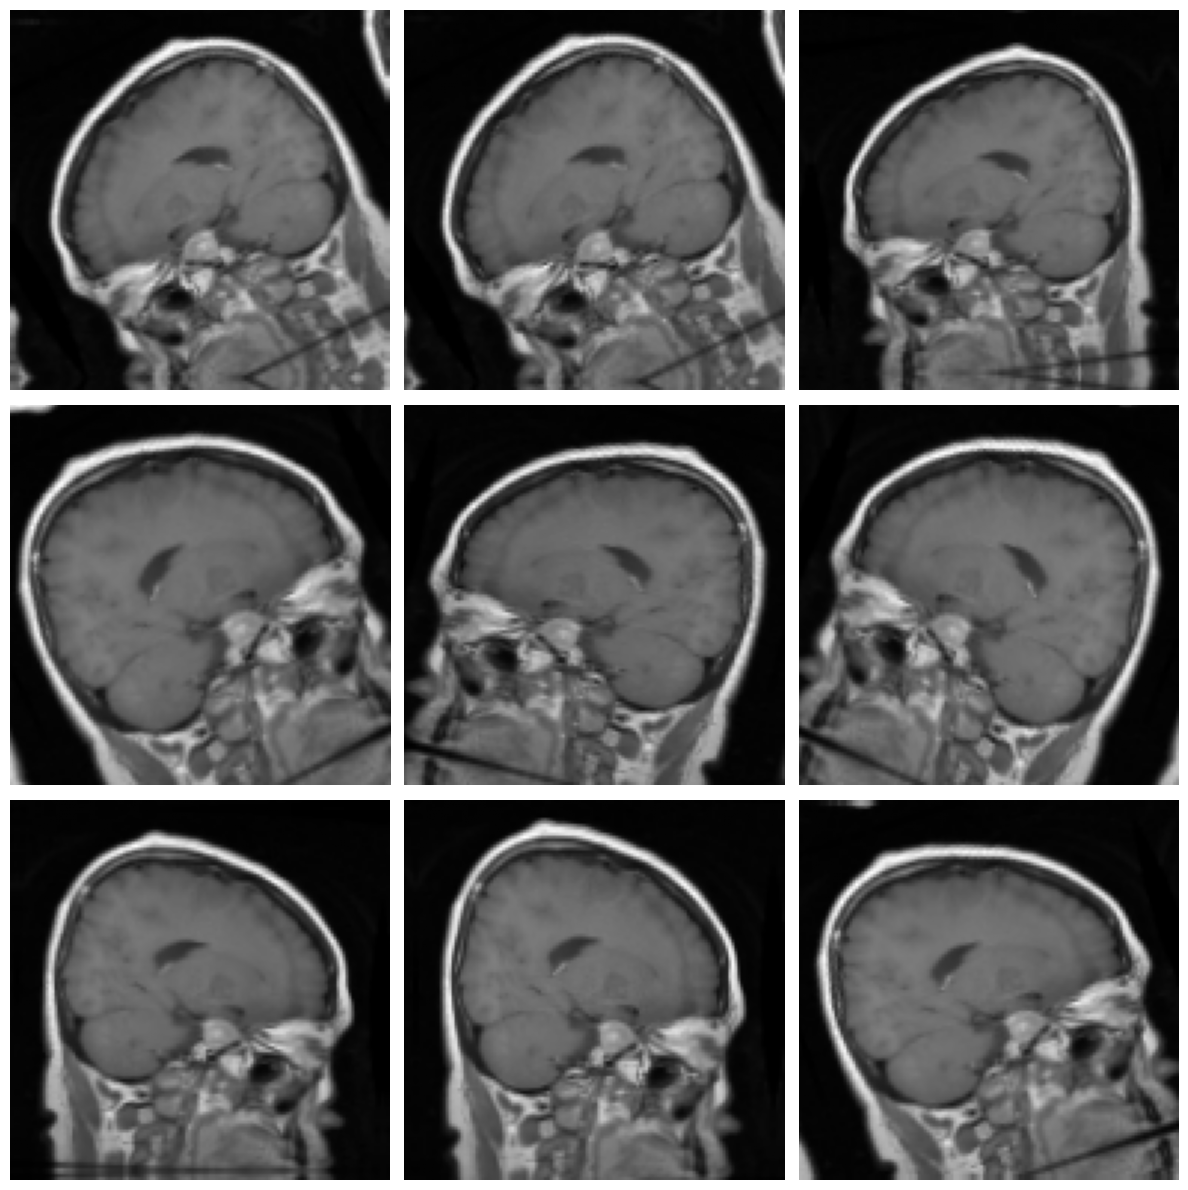

In [19]:
sample = X_train[0]

plt.figure(figsize=(12,12))

for i in range(9):

    augmented = data_augmentation(
        tf.expand_dims(sample, 0),
        training=True
    )

    plt.subplot(3,3,i+1)
    plt.imshow(
        augmented[0].numpy().squeeze(),
        cmap="gray"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [20]:
baseline_model = tf.keras.Sequential([

    layers.Input(shape=(128, 128, 1)),

    data_augmentation,

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Conv2D(
        256,
        (3,3),
        activation="relu",
        padding="same"
    ),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        4,
        activation="softmax"
    )

])

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,428 (17.48 MB)

 Trainable params: 4,583,428 (17.48 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.2,

    patience=4,

    verbose=1

)

In [23]:
history = baseline_model.fit(

    X_train,

    y_train_cat,

    validation_split=0.2,

    epochs=40,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1

)

Epoch 1/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.5837 - loss: 0.9603 - val_accuracy: 0.7154 - val_loss: 0.6915 - learning_rate: 0.0010
Epoch 2/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7268 - loss: 0.6802 - val_accuracy: 0.7132 - val_loss: 0.8366 - learning_rate: 0.0010
Epoch 3/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7801 - loss: 0.5652 - val_accuracy: 0.7444 - val_loss: 0.6427 - learning_rate: 0.0010
Epoch 4/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7941 - loss: 0.5262 - val_accuracy: 0.8036 - val_loss: 0.4990 - learning_rate: 0.0010
Epoch 5/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8242 - loss: 0.4623 - val_accuracy: 0.7645 - val_loss: 0.6204 - learning_rate: 0.0010
Epoch 6/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8477 - loss: 0.3954 - val_accuracy: 0.7065 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 7/40
112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8800 - loss: 0.

In [24]:
print(X_test.shape)

print(y_test.shape)

print(type(X_test), type(y_test))

(1120, 128, 128, 1)
(1120,)
<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [25]:
baseline_model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy"
    ]

)

test_loss, test_acc = baseline_model.evaluate(
    X_test,
    y_test_cat,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7830 - loss: 0.5231
Test Accuracy: 0.7830
Test Loss: 0.5231


In [26]:
y_pred_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [27]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

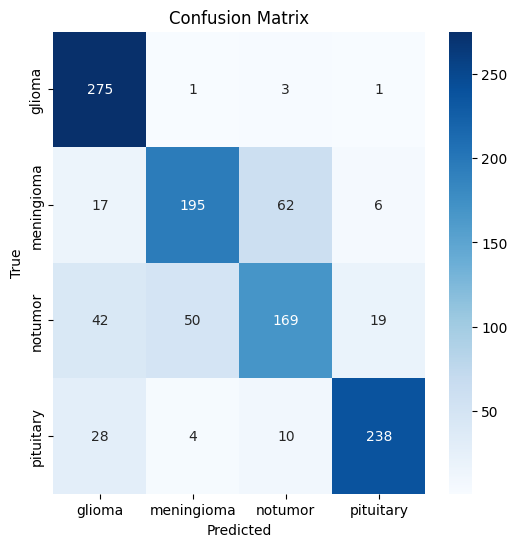

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.76      0.98      0.86       280
  meningioma       0.78      0.70      0.74       280
     notumor       0.69      0.60      0.65       280
   pituitary       0.90      0.85      0.88       280

    accuracy                           0.78      1120
   macro avg       0.78      0.78      0.78      1120
weighted avg       0.78      0.78      0.78      1120



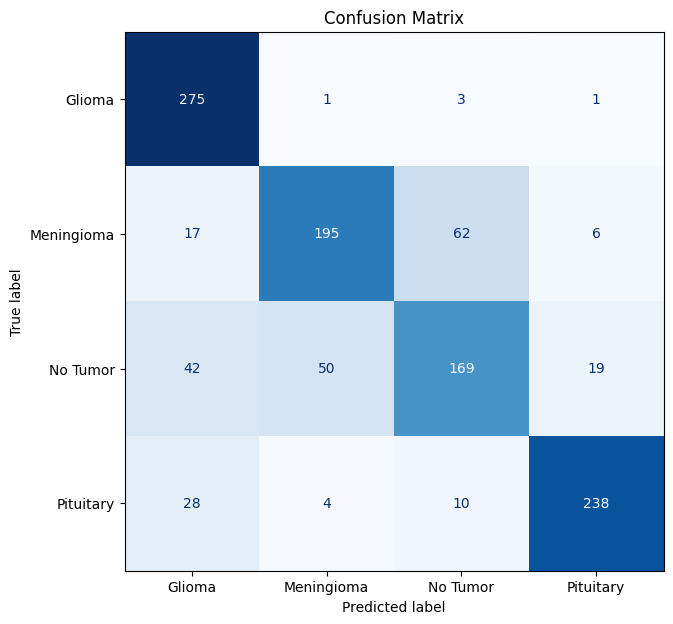

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=class_names)

fig, ax = plt.subplots(figsize=(7,7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

Number of misclassified images: 243


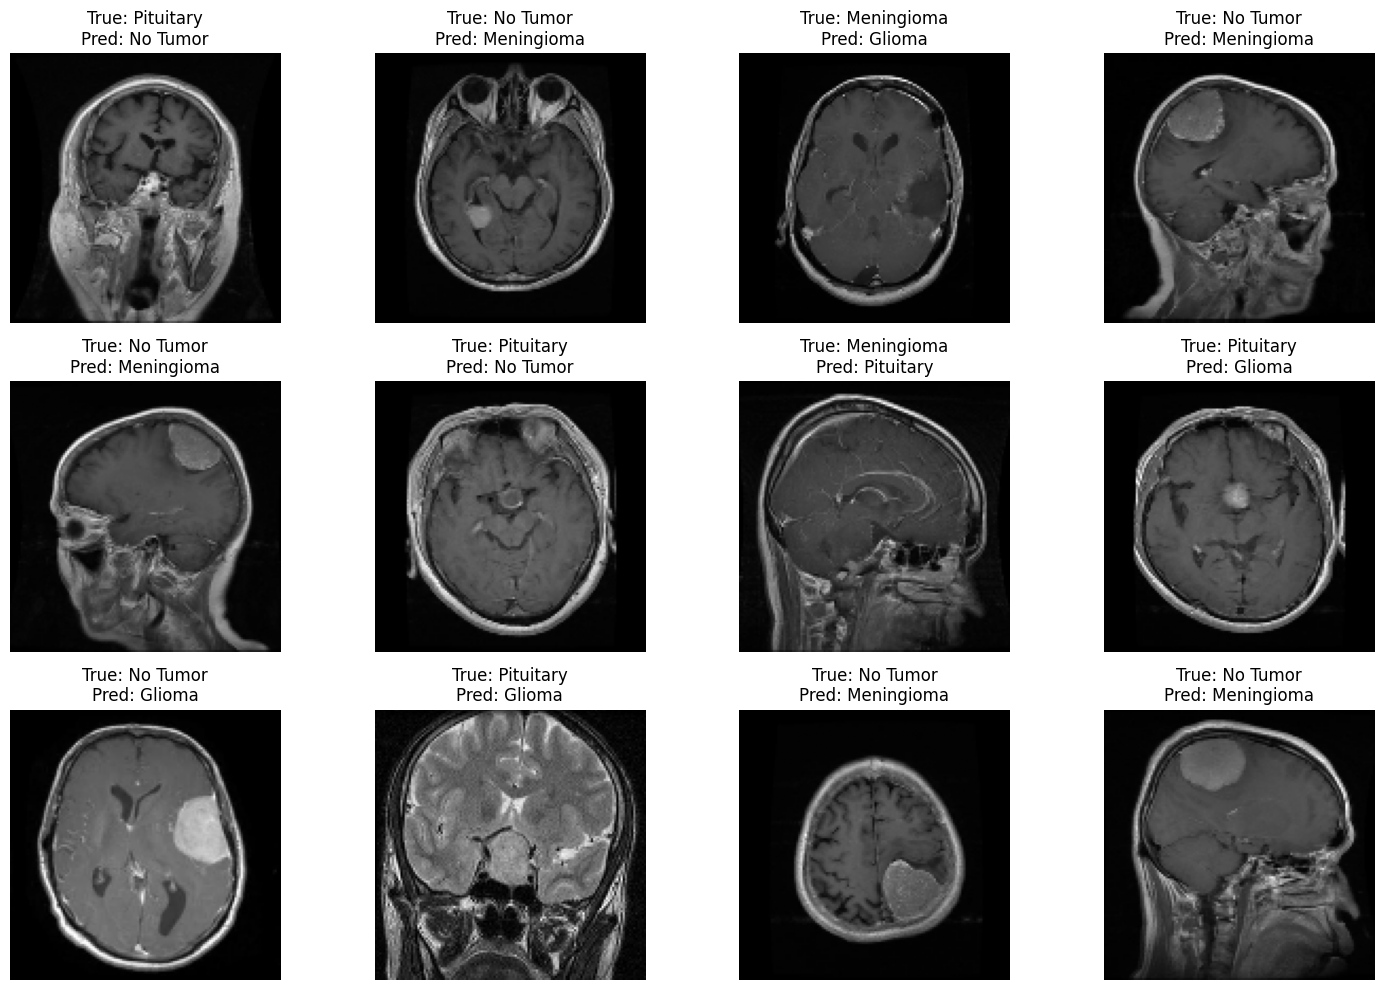

In [31]:
import numpy as np
import matplotlib.pyplot as plt

misclassified = np.where(y_true != y_pred)[0]

print(f"Number of misclassified images: {len(misclassified)}")

plt.figure(figsize=(15,10))

for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[idx].squeeze(), cmap="gray")
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [32]:
for layer in baseline_model.layers:
    print(layer.name)

data_augmentation
conv2d
max_pooling2d
conv2d_1
max_pooling2d_1
conv2d_2
max_pooling2d_2
conv2d_3
max_pooling2d_3
flatten
dense
dropout
dense_1


In [33]:
import numpy as np

X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb  = np.repeat(X_test, 3, axis=-1)

print(X_train_rgb.shape)
print(X_test_rgb.shape)

(4480, 128, 128, 3)
(1120, 128, 128, 3)


In [34]:
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model

In [35]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [36]:
base_model.trainable = False

In [37]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

vgg16_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [38]:
vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [39]:
vgg16_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,044 (56.64 MB)

 Trainable params: 132,356 (517.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=4,
    min_lr=1e-6
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_vgg16.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [41]:
history_vgg16 = vgg16_model.fit(
    X_train_rgb,
    y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 23s 96ms/step - accuracy: 0.3509 - loss: 1.3754 - val_accuracy: 0.6232 - val_loss: 1.0828 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - accuracy: 0.5696 - loss: 1.0453 - val_accuracy: 0.7304 - val_loss: 0.8950 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - accuracy: 0.6808 - loss: 0.8710 - val_accuracy: 0.7598 - val_loss: 0.7831 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step - accuracy: 0.7413 - loss: 0.7614 - val_accuracy: 0.7786 - val_loss: 0.7077 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.7598 - loss: 0.6987 - val_accuracy: 0.7937 - val_loss: 0.6524 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.7821 - loss: 0.6397 - val_accuracy: 0.8036 - val_loss: 0.6113 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/ste

In [42]:
test_loss, test_acc = vgg16_model.evaluate(
    X_test_rgb,
    y_test_cat,
    verbose=1
)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8679 - loss: 0.3735
Test Accuracy: 0.8679
Test Loss: 0.3735


In [43]:
import numpy as np

y_pred_prob = vgg16_model.predict(X_test_rgb)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.argmax(y_test_cat, axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step


In [44]:
from sklearn.metrics import classification_report

class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.94      0.91      0.93       280
  meningioma       0.86      0.81      0.83       280
     notumor       0.75      0.80      0.77       280
   pituitary       0.93      0.95      0.94       280

    accuracy                           0.87      1120
   macro avg       0.87      0.87      0.87      1120
weighted avg       0.87      0.87      0.87      1120



In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[256   3  18   3]
 [  1 226  50   3]
 [ 13  30 223  14]
 [  2   4   7 267]]


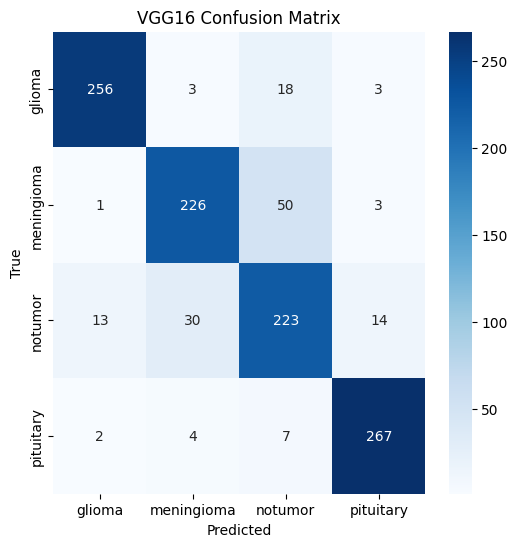

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("VGG16 Confusion Matrix")

plt.show()

In [72]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

In [73]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

In [74]:
base_model.trainable = False

In [75]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

resnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [76]:
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [77]:
resnet_model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [78]:
checkpoint_resnet = tf.keras.callbacks.ModelCheckpoint(
    "best_resnet50.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [79]:
import numpy as np

# Convert grayscale (128,128,1) → RGB (128,128,3)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print(X_train_rgb.shape)
print(X_test_rgb.shape)

(4480, 128, 128, 3)
(1120, 128, 128, 3)


In [80]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Convert [0,1] → preprocess format expected by ResNet50
X_train_rgb = preprocess_input(X_train_rgb * 255.0)
X_test_rgb = preprocess_input(X_test_rgb * 255.0)

In [81]:
history_resnet = resnet_model.fit(
    X_train_rgb,
    y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_resnet
    ]
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.6391 - loss: 1.0010 - val_accuracy: 0.8277 - val_loss: 0.4886 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8016 - loss: 0.5109 - val_accuracy: 0.8527 - val_loss: 0.4097 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8458 - loss: 0.4120 - val_accuracy: 0.8687 - val_loss: 0.3661 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8594 - loss: 0.3598 - val_accuracy: 0.8821 - val_loss: 0.3368 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.8821 - loss: 0.3115 - val_accuracy: 0.8839 - val_loss: 0.3204 - learning_rate: 1.0000e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 47ms/step - accuracy: 0.9054 - loss: 0.2683 - val_accuracy: 0.8902 - val_loss: 0.3040 - learning_rate: 1.0000e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - ac

In [82]:
test_loss, test_acc = resnet_model.evaluate(
    X_test_rgb,
    y_test_cat,
    verbose=1
)

print("Test Accuracy:", test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9295 - loss: 0.2175
Test Accuracy: 0.9294642806053162


In [83]:
y_pred = resnet_model.predict(X_test_rgb)

35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step


In [85]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

In [86]:
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

              precision    recall  f1-score   support

      glioma       0.97      0.97      0.97       280
  meningioma       0.92      0.90      0.91       280
     notumor       0.87      0.87      0.87       280
   pituitary       0.95      0.98      0.96       280

    accuracy                           0.93      1120
   macro avg       0.93      0.93      0.93      1120
weighted avg       0.93      0.93      0.93      1120



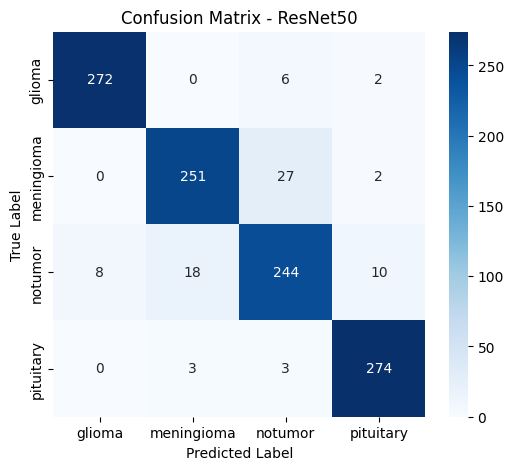

In [87]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet50")

plt.show()

In [88]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

In [89]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [90]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(128, 128, 3)
)

base_model.trainable = False

In [91]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

output = Dense(4, activation="softmax")(x)

densenet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [92]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [93]:
checkpoint_densenet = tf.keras.callbacks.ModelCheckpoint(
    "best_densenet121.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [94]:
import numpy as np

# Convert grayscale (128,128,1) → RGB (128,128,3)
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print(X_train_rgb.shape)
print(X_test_rgb.shape)

(4480, 128, 128, 3)
(1120, 128, 128, 3)


In [95]:
from tensorflow.keras.applications.densenet import preprocess_input

X_train_rgb = preprocess_input(X_train_rgb * 255.0)
X_test_rgb = preprocess_input(X_test_rgb * 255.0)

In [96]:
history_densenet = densenet_model.fit(
    X_train_rgb,
    y_train_cat,
    validation_data=(X_test_rgb, y_test_cat),
    epochs=30,
    batch_size=32,
    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint_densenet
    ]
)

Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 45s 139ms/step - accuracy: 0.5489 - loss: 1.3143 - val_accuracy: 0.7955 - val_loss: 0.5613 - learning_rate: 1.0000e-04
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7502 - loss: 0.6445 - val_accuracy: 0.8330 - val_loss: 0.4593 - learning_rate: 1.0000e-04
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.8002 - loss: 0.5232 - val_accuracy: 0.8527 - val_loss: 0.4166 - learning_rate: 1.0000e-04
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8212 - loss: 0.4662 - val_accuracy: 0.8625 - val_loss: 0.3860 - learning_rate: 1.0000e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.8433 - loss: 0.4260 - val_accuracy: 0.8625 - val_loss: 0.3818 - learning_rate: 2.0000e-05
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.8473 - loss: 0.4123 - val_accuracy: 0.8643 - val_loss: 0.3766 - learning_rate: 2.0000e-05
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - 

In [97]:
test_loss, test_acc = densenet_model.evaluate(
    X_test_rgb,
    y_test_cat,
    verbose=1
)

print("Test Accuracy:", test_acc)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7955 - loss: 0.5613
Test Accuracy: 0.7955357432365417


In [98]:
best_model = tf.keras.models.load_model(
    "best_densenet121.keras"
)

In [99]:
y_pred = best_model.predict(X_test_rgb)

y_pred_classes = y_pred.argmax(axis=1)
y_true = y_test_cat.argmax(axis=1)

35/35 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step


In [100]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.94      0.92      0.93       280
  meningioma       0.90      0.79      0.84       280
     notumor       0.75      0.80      0.77       280
   pituitary       0.90      0.96      0.93       280

    accuracy                           0.87      1120
   macro avg       0.87      0.87      0.87      1120
weighted avg       0.87      0.87      0.87      1120



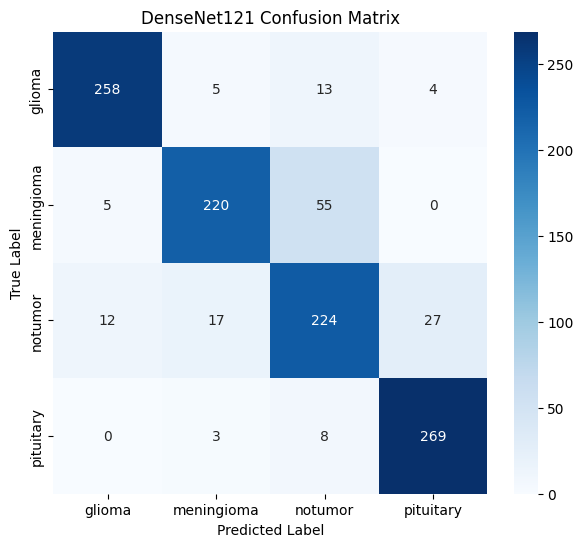

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("DenseNet121 Confusion Matrix")

plt.show()

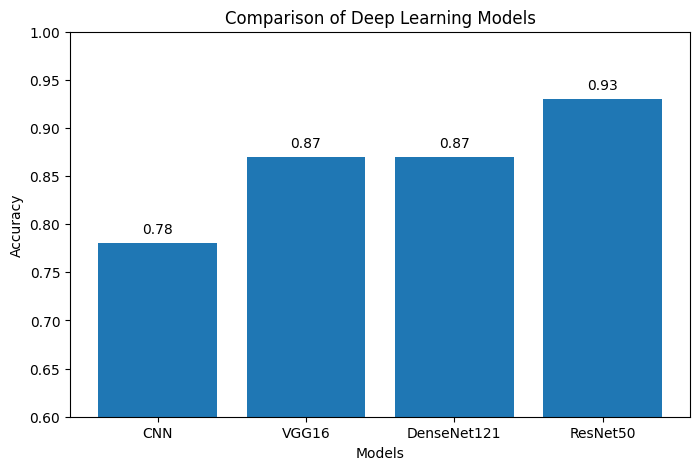

In [103]:
import matplotlib.pyplot as plt

models = [
    "CNN",
    "VGG16",
    "DenseNet121",
    "ResNet50"
]

accuracies = [
    0.78,
    0.87,
    0.87,
    0.93
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, accuracies)

plt.ylim(0.6,1.0)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of Deep Learning Models")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.01,
        f"{y:.2f}",
        ha="center"
    )

plt.show()

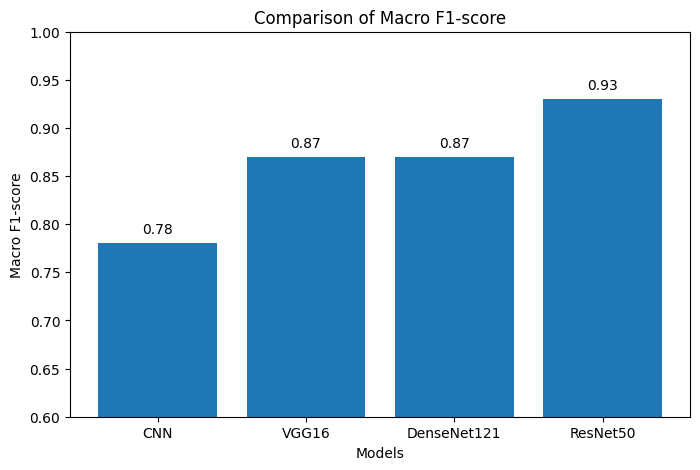

In [104]:
import matplotlib.pyplot as plt

models = [
    "CNN",
    "VGG16",
    "DenseNet121",
    "ResNet50"
]

f1_scores = [
    0.78,
    0.87,
    0.87,
    0.93
]

plt.figure(figsize=(8,5))

bars = plt.bar(models, f1_scores)

plt.ylim(0.6,1.0)

plt.xlabel("Models")
plt.ylabel("Macro F1-score")
plt.title("Comparison of Macro F1-score")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.01,
        f"{y:.2f}",
        ha="center"
    )

plt.show()